In [ ]:
# ============================================================
# CELL 1 — IMPORTS + PATHS
# ============================================================

from pathlib import Path

import numpy as np
import pandas as pd

import torch
import torch.nn as nn

from torch.utils.data import Dataset, DataLoader


# Run this notebook from the notebooks/ directory.
PROJECT_ROOT = Path("..").resolve()

POSITIVE_ROOT = PROJECT_ROOT / "data" / "center_detection_v1"
COMBINED_ROOT = PROJECT_ROOT / "data" / "center_detection_v2"
MODEL_ROOT = PROJECT_ROOT / "models"
RESULTS_ROOT = PROJECT_ROOT / "results"

MODEL_ROOT.mkdir(parents=True, exist_ok=True)
RESULTS_ROOT.mkdir(parents=True, exist_ok=True)

COMBINED_MANIFEST_PATH = COMBINED_ROOT / "combined_manifest.csv"
BEST_MODEL_PATH = MODEL_ROOT / "best_model.pt"
FINAL_MODEL_PATH = MODEL_ROOT / "center_detection_experiment_03_final.pt"
MSLP_MEAN_PATH = MODEL_ROOT / "mslp_mean.npy"
MSLP_STD_PATH = MODEL_ROOT / "mslp_std.npy"
TEST_PREDICTIONS_PATH = RESULTS_ROOT / "test_predictions.csv"

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", DEVICE)
print("Positive data:", POSITIVE_ROOT)
print("Combined data:", COMBINED_ROOT)
print("Models:", MODEL_ROOT)
print("Results:", RESULTS_ROOT)


In [3]:
# ============================================================
# CELL 2 — LOAD COMBINED DATASET
# ============================================================

manifest = pd.read_csv(
    COMBINED_MANIFEST_PATH
)

manifest["timestamp"] = pd.to_datetime(
    manifest["timestamp"],
    format="mixed",
    utc=True,
)


positive_mslp = np.load(
    POSITIVE_ROOT / "mslp.npy",
    mmap_mode="r",
)

positive_heatmaps = np.load(
    POSITIVE_ROOT / "target_heatmap.npy",
    mmap_mode="r",
)


latitude = np.load(
    POSITIVE_ROOT / "latitude.npy"
)

longitude = np.load(
    POSITIVE_ROOT / "longitude.npy"
)


print("=" * 72)
print("CENTER DETECTION EXPERIMENT 03")
print("=" * 72)

print("Samples:", len(manifest))

print()
print(
    pd.crosstab(
        manifest["split"],
        manifest["presence"],
        margins=True,
    )
)

print()
print(
    "Positive MSLP:",
    positive_mslp.shape
)

print(
    "Positive heatmaps:",
    positive_heatmaps.shape
)

CENTER DETECTION EXPERIMENT 03
Samples: 3800

presence       0     1   All
split                       
test         341   341   682
train       1336  1336  2672
validation   223   223   446
All         1900  1900  3800

Positive MSLP: (1900, 1, 121, 121)
Positive heatmaps: (1900, 1, 121, 121)


In [4]:
# ============================================================
# CELL 3 — SPLIT INDICES
# ============================================================

train_indices = (
    manifest.index[
        manifest["split"] == "train"
    ]
    .to_numpy()
)

val_indices = (
    manifest.index[
        manifest["split"] == "validation"
    ]
    .to_numpy()
)

test_indices = (
    manifest.index[
        manifest["split"] == "test"
    ]
    .to_numpy()
)


print("Train:", len(train_indices))
print("Validation:", len(val_indices))
print("Test:", len(test_indices))

Train: 2672
Validation: 446
Test: 682


In [ ]:
# ============================================================
# CELL 4 — TRAINING-ONLY COMBINED MSLP NORMALIZATION
# ============================================================

sum_x = 0.0
sum_x2 = 0.0
count = 0


for dataset_index in train_indices:

    row = manifest.iloc[
        dataset_index
    ]

    # --------------------------------------------------------
    # Positive sample
    # --------------------------------------------------------

    if row["source_type"] == "positive_array":

        array_index = int(
            row["positive_array_index"]
        )

        frame = np.asarray(
            positive_mslp[
                array_index,
                0
            ],
            dtype=np.float64,
        )

    # --------------------------------------------------------
    # Negative sample
    # --------------------------------------------------------

    else:

        input_path = COMBINED_ROOT / "negative_inputs" / Path(row["input_path"]).name

        x = np.load(
            input_path
        )

        frame = np.asarray(
            x[0],
            dtype=np.float64,
        )

    sum_x += frame.sum()
    sum_x2 += np.square(
        frame
    ).sum()

    count += frame.size


MSLP_MEAN = (
    sum_x
    /
    count
)


MSLP_VAR = (
    sum_x2 / count
    -
    MSLP_MEAN ** 2
)


MSLP_STD = np.sqrt(
    max(
        MSLP_VAR,
        1e-12,
    )
)


print("=" * 72)
print("COMBINED TRAINING NORMALIZATION")
print("=" * 72)

print(
    "MSLP mean:",
    MSLP_MEAN
)

print(
    "MSLP std:",
    MSLP_STD
)


np.save(
    MSLP_MEAN_PATH,
    np.array(
        MSLP_MEAN,
        dtype=np.float32,
    ),
)

np.save(
    MSLP_STD_PATH,
    np.array(
        MSLP_STD,
        dtype=np.float32,
    ),
)

COMBINED TRAINING NORMALIZATION
MSLP mean: 1009.7690250011224
MSLP std: 4.757597109605514


In [ ]:
# ============================================================
# CELL 5 — PRESENCE + LOCALIZATION DATASET
# ============================================================

class CyclonePresenceLocalizationDataset(
    Dataset
):

    def __init__(
        self,
        indices,
        manifest,
        positive_mslp,
        positive_heatmaps,
        mean,
        std,
    ):

        self.indices = np.asarray(
            indices,
            dtype=np.int64,
        )

        self.manifest = manifest
        self.positive_mslp = (
            positive_mslp
        )

        self.positive_heatmaps = (
            positive_heatmaps
        )

        self.mean = float(mean)
        self.std = float(std)

    def __len__(self):

        return len(
            self.indices
        )

    def __getitem__(
        self,
        item,
    ):

        dataset_index = int(
            self.indices[item]
        )

        row = self.manifest.iloc[
            dataset_index
        ]

        # ====================================================
        # POSITIVE
        # ====================================================

        if (
            row["source_type"]
            ==
            "positive_array"
        ):

            array_index = int(
                row[
                    "positive_array_index"
                ]
            )

            x = np.array(
                self.positive_mslp[
                    array_index
                ],
                dtype=np.float32,
                copy=True,
            )

            heatmap = np.array(
                self.positive_heatmaps[
                    array_index
                ],
                dtype=np.float32,
                copy=True,
            )

        # ====================================================
        # NEGATIVE
        # ====================================================

        else:

            input_path = COMBINED_ROOT / "negative_inputs" / Path(row["input_path"]).name
            target_path = COMBINED_ROOT / "negative_targets" / Path(row["target_path"]).name

            x = np.load(
                input_path
            ).astype(
                np.float32
            )

            heatmap = np.load(
                target_path
            ).astype(
                np.float32
            )

        # ----------------------------------------------------
        # Normalize MSLP
        # ----------------------------------------------------

        x = (
            x
            -
            self.mean
        ) / self.std

        presence = np.float32(
            row["presence"]
        )

        return (
            torch.from_numpy(x),

            torch.from_numpy(
                heatmap
            ),

            torch.tensor(
                presence,
                dtype=torch.float32,
            ),

            dataset_index,
        )

In [7]:
# ============================================================
# CELL 6 — DATASETS + LOADERS
# ============================================================

train_dataset = (
    CyclonePresenceLocalizationDataset(
        train_indices,
        manifest,
        positive_mslp,
        positive_heatmaps,
        MSLP_MEAN,
        MSLP_STD,
    )
)


val_dataset = (
    CyclonePresenceLocalizationDataset(
        val_indices,
        manifest,
        positive_mslp,
        positive_heatmaps,
        MSLP_MEAN,
        MSLP_STD,
    )
)


test_dataset = (
    CyclonePresenceLocalizationDataset(
        test_indices,
        manifest,
        positive_mslp,
        positive_heatmaps,
        MSLP_MEAN,
        MSLP_STD,
    )
)


BATCH_SIZE = 16


train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
)


val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
)


test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
)


x, heatmap, presence, indices = next(
    iter(train_loader)
)


print("Input:", x.shape)
print("Heatmap:", heatmap.shape)
print("Presence:", presence.shape)
print("Indices:", indices.shape)

print(
    "Presence values:",
    torch.unique(
        presence
    )
)

Input: torch.Size([16, 1, 121, 121])
Heatmap: torch.Size([16, 1, 121, 121])
Presence: torch.Size([16])
Indices: torch.Size([16])
Presence values: tensor([0., 1.])


In [ ]:
# ============================================================
# CELL 7 — PRESENCE + LOCALIZATION MODEL
# ============================================================

class ConvBlock(nn.Module):

    def __init__(
        self,
        in_channels,
        out_channels,
    ):

        super().__init__()

        self.block = nn.Sequential(

            nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=3,
                padding=1,
            ),

            nn.BatchNorm2d(
                out_channels
            ),

            nn.ReLU(),

            nn.Conv2d(
                out_channels,
                out_channels,
                kernel_size=3,
                padding=1,
            ),

            nn.BatchNorm2d(
                out_channels
            ),

            nn.ReLU(),
        )

    def forward(
        self,
        x,
    ):

        return self.block(x)


class CyclonePresenceLocalizationModel(
    nn.Module
):

    def __init__(
        self,
    ):

        super().__init__()

        # ====================================================
        # SHARED ENCODER
        # ====================================================

        self.enc1 = ConvBlock(
            1,
            16,
        )

        self.pool1 = nn.MaxPool2d(2)

        self.enc2 = ConvBlock(
            16,
            32,
        )

        self.pool2 = nn.MaxPool2d(2)

        self.enc3 = ConvBlock(
            32,
            64,
        )

        self.pool3 = nn.MaxPool2d(2)

        self.bottleneck = ConvBlock(
            64,
            128,
        )

        # ====================================================
        # PRESENCE HEAD
        # ====================================================

        self.presence_head = nn.Sequential(

            nn.AdaptiveAvgPool2d(
                (1, 1)
            ),

            nn.Flatten(),

            nn.Linear(
                128,
                64,
            ),

            nn.ReLU(),

            nn.Dropout(
                0.25
            ),

            nn.Linear(
                64,
                1,
            ),
        )

        # ====================================================
        # LOCALIZATION DECODER
        # ====================================================

        self.up3 = nn.ConvTranspose2d(
            128,
            64,
            kernel_size=2,
            stride=2,
        )

        self.dec3 = ConvBlock(
            128,
            64,
        )

        self.up2 = nn.ConvTranspose2d(
            64,
            32,
            kernel_size=2,
            stride=2,
        )

        self.dec2 = ConvBlock(
            64,
            32,
        )

        self.up1 = nn.ConvTranspose2d(
            32,
            16,
            kernel_size=2,
            stride=2,
        )

        self.dec1 = ConvBlock(
            32,
            16,
        )

        self.heatmap_head = nn.Conv2d(
            16,
            1,
            kernel_size=1,
        )

    def forward(
        self,
        x,
    ):

        # ----------------------------------------------------
        # Shared encoder
        # ----------------------------------------------------

        e1 = self.enc1(x)

        e2 = self.enc2(
            self.pool1(e1)
        )

        e3 = self.enc3(
            self.pool2(e2)
        )

        b = self.bottleneck(
            self.pool3(e3)
        )

        # ----------------------------------------------------
        # Presence
        # ----------------------------------------------------

        presence_logit = (
            self.presence_head(
                b
            )
            .squeeze(1)
        )

        # ----------------------------------------------------
        # Localization decoder
        # ----------------------------------------------------

        d3 = self.up3(b)

        d3 = nn.functional.interpolate(
            d3,
            size=e3.shape[-2:],
            mode="bilinear",
            align_corners=False,
        )

        d3 = torch.cat(
            [d3, e3],
            dim=1,
        )

        d3 = self.dec3(d3)

        d2 = self.up2(d3)

        d2 = nn.functional.interpolate(
            d2,
            size=e2.shape[-2:],
            mode="bilinear",
            align_corners=False,
        )

        d2 = torch.cat(
            [d2, e2],
            dim=1,
        )

        d2 = self.dec2(d2)

        d1 = self.up1(d2)

        d1 = nn.functional.interpolate(
            d1,
            size=e1.shape[-2:],
            mode="bilinear",
            align_corners=False,
        )

        d1 = torch.cat(
            [d1, e1],
            dim=1,
        )

        d1 = self.dec1(d1)

        heatmap_logits = (
            self.heatmap_head(
                d1
            )
        )

        return (
            presence_logit,
            heatmap_logits,
        )

In [9]:
# ============================================================
# CELL 8 — MODEL SANITY CHECK
# ============================================================

model = (
    CyclonePresenceLocalizationModel()
    .to(DEVICE)
)


with torch.no_grad():

    presence_logits, heatmap_logits = (
        model(
            x.to(DEVICE)
        )
    )


print("=" * 72)
print("MULTI-TASK MODEL")
print("=" * 72)

print(
    "Presence:",
    presence_logits.shape
)

print(
    "Heatmap:",
    heatmap_logits.shape
)

print(
    "Parameters:",
    f"{sum(p.numel() for p in model.parameters()):,}"
)


assert presence_logits.shape == (
    x.shape[0],
)

assert heatmap_logits.shape == (
    x.shape[0],
    1,
    121,
    121,
)

print(
    "✓ Forward pass successful."
)

MULTI-TASK MODEL
Presence: torch.Size([16])
Heatmap: torch.Size([16, 1, 121, 121])
Parameters: 491,474
✓ Forward pass successful.


In [ ]:
# ============================================================
# CELL 9 — MULTI-TASK LOSS
# ============================================================

presence_bce = (
    nn.BCEWithLogitsLoss()
)

heatmap_bce = (
    nn.BCEWithLogitsLoss()
)


LOCALIZATION_WEIGHT = 1.0


def compute_loss(
    presence_logits,
    heatmap_logits,
    target_presence,
    target_heatmap,
):

    # --------------------------------------------------------
    # Presence loss:
    # all samples
    # --------------------------------------------------------

    presence_loss = (
        presence_bce(
            presence_logits,
            target_presence,
        )
    )

    # --------------------------------------------------------
    # Localization:
    # positive samples only
    # --------------------------------------------------------

    positive_mask = (
        target_presence
        >
        0.5
    )

    if positive_mask.any():

        positive_logits = (
            heatmap_logits[
                positive_mask
            ]
        )

        positive_targets = (
            target_heatmap[
                positive_mask
            ]
        )

        probability = torch.sigmoid(
            positive_logits
        )

        mse = nn.functional.mse_loss(
            probability,
            positive_targets,
        )

        bce = heatmap_bce(
            positive_logits,
            positive_targets,
        )

        localization_loss = (
            0.25 * mse
            +
            0.75 * bce
        )

    else:

        localization_loss = (
            presence_loss
            *
            0.0
        )

    total_loss = (
        presence_loss
        +
        LOCALIZATION_WEIGHT
        *
        localization_loss
    )

    return {
        "total":
            total_loss,

        "presence":
            presence_loss,

        "localization":
            localization_loss,
    }

In [ ]:
# ============================================================
# CELL 10 — METRIC HELPERS
# ============================================================

def haversine_km(
    lat1,
    lon1,
    lat2,
    lon2,
):

    R = 6371.0

    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)

    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = (
        np.sin(
            dlat / 2.0
        ) ** 2

        +

        np.cos(lat1)
        *
        np.cos(lat2)
        *
        np.sin(
            dlon / 2.0
        ) ** 2
    )

    c = (
        2.0
        *
        np.arctan2(
            np.sqrt(a),
            np.sqrt(
                1.0 - a
            ),
        )
    )

    return R * c


def heatmap_peak_indices(
    heatmaps,
):

    heatmaps = heatmaps[
        :,
        0,
        :,
        :
    ]

    batch_size = (
        heatmaps.shape[0]
    )

    flat_index = (
        heatmaps
        .reshape(
            batch_size,
            -1,
        )
        .argmax(
            dim=1
        )
    )

    rows = (
        flat_index
        //
        heatmaps.shape[2]
    )

    cols = (
        flat_index
        %
        heatmaps.shape[2]
    )

    return (
        rows,
        cols,
    )

In [ ]:
# ============================================================
# CELL 11 — PRESENCE METRICS
# ============================================================

def binary_metrics(
    true,
    pred,
):

    true = np.asarray(
        true,
        dtype=np.int64,
    )

    pred = np.asarray(
        pred,
        dtype=np.int64,
    )

    tp = np.sum(
        (true == 1)
        &
        (pred == 1)
    )

    tn = np.sum(
        (true == 0)
        &
        (pred == 0)
    )

    fp = np.sum(
        (true == 0)
        &
        (pred == 1)
    )

    fn = np.sum(
        (true == 1)
        &
        (pred == 0)
    )

    accuracy = (
        tp + tn
    ) / len(true)

    precision = (
        tp
        /
        max(
            tp + fp,
            1,
        )
    )

    recall = (
        tp
        /
        max(
            tp + fn,
            1,
        )
    )

    f1 = (
        2
        *
        precision
        *
        recall
        /
        max(
            precision + recall,
            1e-12,
        )
    )

    return {
        "accuracy":
            accuracy,

        "precision":
            precision,

        "recall":
            recall,

        "f1":
            f1,

        "tp":
            tp,

        "tn":
            tn,

        "fp":
            fp,

        "fn":
            fn,
    }

In [ ]:
# ============================================================
# CELL 12 — RUN ONE EPOCH
# ============================================================

def run_epoch(
    model,
    loader,
    optimizer=None,
):

    training = (
        optimizer is not None
    )

    if training:
        model.train()
    else:
        model.eval()

    total_loss = 0.0
    total_presence_loss = 0.0
    total_localization_loss = 0.0
    total_samples = 0

    presence_true = []
    presence_pred = []

    localization_errors = []

    for (
        x,
        target_heatmap,
        target_presence,
        indices,
    ) in loader:

        x = x.to(
            DEVICE
        )

        target_heatmap = target_heatmap.to(
            DEVICE
        )

        target_presence = target_presence.to(
            DEVICE
        )

        if training:

            optimizer.zero_grad(
                set_to_none=True
            )

        with torch.set_grad_enabled(
            training
        ):

            (
                presence_logits,
                heatmap_logits,
            ) = model(x)

            losses = compute_loss(
                presence_logits,
                heatmap_logits,
                target_presence,
                target_heatmap,
            )

            loss = losses["total"]

            if training:

                loss.backward()

                torch.nn.utils.clip_grad_norm_(
                    model.parameters(),
                    max_norm=5.0,
                )

                optimizer.step()

        batch_size = x.size(0)

        total_loss += (
            losses["total"].item()
            *
            batch_size
        )

        total_presence_loss += (
            losses["presence"].item()
            *
            batch_size
        )

        total_localization_loss += (
            losses["localization"].item()
            *
            batch_size
        )

        total_samples += batch_size

        # ----------------------------------------------------
        # Presence predictions
        # ----------------------------------------------------

        presence_prob = torch.sigmoid(
            presence_logits
        )

        pred_presence = (
            presence_prob
            >=
            0.5
        ).long()

        presence_true.extend(
            target_presence
            .detach()
            .cpu()
            .numpy()
            .astype(int)
        )

        presence_pred.extend(
            pred_presence
            .detach()
            .cpu()
            .numpy()
            .astype(int)
        )

        # ----------------------------------------------------
        # Localization metric:
        # evaluate on TRUE positive samples only
        # ----------------------------------------------------

        positive_mask = (
            target_presence
            >
            0.5
        )

        if positive_mask.any():

            positive_heatmaps = torch.sigmoid(
                heatmap_logits[
                    positive_mask
                ]
            )

            pred_rows, pred_cols = (
                heatmap_peak_indices(
                    positive_heatmaps
                )
            )

            pred_rows = (
                pred_rows
                .detach()
                .cpu()
                .numpy()
            )

            pred_cols = (
                pred_cols
                .detach()
                .cpu()
                .numpy()
            )

            positive_indices = (
                indices[
                    positive_mask.cpu()
                ]
                .numpy()
            )

            for j in range(
                len(
                    positive_indices
                )
            ):

                dataset_index = int(
                    positive_indices[j]
                )

                pred_lat = float(
                    latitude[
                        pred_rows[j]
                    ]
                )

                pred_lon = float(
                    longitude[
                        pred_cols[j]
                    ]
                )

                true_lat = float(
                    manifest.iloc[
                        dataset_index
                    ][
                        "center_lat"
                    ]
                )

                true_lon = float(
                    manifest.iloc[
                        dataset_index
                    ][
                        "center_lon"
                    ]
                )

                error = haversine_km(
                    true_lat,
                    true_lon,
                    pred_lat,
                    pred_lon,
                )

                localization_errors.append(
                    error
                )

    # ========================================================
    # Presence metrics
    # ========================================================

    presence_results = binary_metrics(
        presence_true,
        presence_pred,
    )

    # ========================================================
    # Localization metrics
    # ========================================================

    localization_errors = np.asarray(
        localization_errors,
        dtype=np.float64,
    )

    if len(
        localization_errors
    ) > 0:

        mean_error = (
            localization_errors.mean()
        )

        median_error = (
            np.median(
                localization_errors
            )
        )

        within_25 = np.mean(
            localization_errors
            <=
            25
        )

        within_50 = np.mean(
            localization_errors
            <=
            50
        )

        within_100 = np.mean(
            localization_errors
            <=
            100
        )

    else:

        mean_error = np.nan
        median_error = np.nan
        within_25 = np.nan
        within_50 = np.nan
        within_100 = np.nan

    return {
        "loss":
            total_loss
            /
            total_samples,

        "presence_loss":
            total_presence_loss
            /
            total_samples,

        "localization_loss":
            total_localization_loss
            /
            total_samples,

        "presence_accuracy":
            presence_results[
                "accuracy"
            ],

        "presence_precision":
            presence_results[
                "precision"
            ],

        "presence_recall":
            presence_results[
                "recall"
            ],

        "presence_f1":
            presence_results[
                "f1"
            ],

        "tp":
            presence_results["tp"],

        "tn":
            presence_results["tn"],

        "fp":
            presence_results["fp"],

        "fn":
            presence_results["fn"],

        "mean_error_km":
            mean_error,

        "median_error_km":
            median_error,

        "within_25_km":
            within_25,

        "within_50_km":
            within_50,

        "within_100_km":
            within_100,
    }

In [14]:
# ============================================================
# CELL 13 — TRAINING CONFIG
# ============================================================

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-4,
)


scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=5,
)


EPOCHS = 100

EARLY_STOPPING_PATIENCE = 25


print("Epochs:", EPOCHS)

print(
    "Early stopping patience:",
    EARLY_STOPPING_PATIENCE
)

Epochs: 100
Early stopping patience: 25


In [ ]:
# ============================================================
# CELL 14 — CHECKPOINT SCORE
# ============================================================

def validation_score(
    metrics,
):

    f1 = (
        metrics[
            "presence_f1"
        ]
    )

    error = (
        metrics[
            "mean_error_km"
        ]
    )

    # Localization component:
    # 1.0 when error = 0
    # gradually decreases as error grows
    localization_score = (
        1.0
        /
        (
            1.0
            +
            error / 100.0
        )
    )

    # Presence is slightly more important
    score = (
        0.60 * f1
        +
        0.40 * localization_score
    )

    return score

In [ ]:
# ============================================================
# CELL 15 — TRAIN EXPERIMENT 03
# ============================================================

history = []

best_score = -np.inf

epochs_without_improvement = 0


for epoch in range(
    1,
    EPOCHS + 1,
):

    # --------------------------------------------------------
    # Train
    # --------------------------------------------------------

    train_metrics = run_epoch(
        model,
        train_loader,
        optimizer=optimizer,
    )

    # --------------------------------------------------------
    # Validation
    # --------------------------------------------------------

    val_metrics = run_epoch(
        model,
        val_loader,
        optimizer=None,
    )

    current_score = validation_score(
        val_metrics
    )

    scheduler.step(
        current_score
    )

    current_lr = (
        optimizer
        .param_groups[0]["lr"]
    )

    history.append(
        {
            "epoch":
                epoch,

            "lr":
                current_lr,

            "val_score":
                current_score,

            **{
                f"train_{k}": v
                for k, v
                in train_metrics.items()
            },

            **{
                f"val_{k}": v
                for k, v
                in val_metrics.items()
            },
        }
    )

    print(
        f"Epoch {epoch:03d} | "
        f"train loss={train_metrics['loss']:.4f} "
        f"F1={train_metrics['presence_f1']:.3f} "
        f"loc={train_metrics['mean_error_km']:.1f} km | "
        f"val loss={val_metrics['loss']:.4f} "
        f"F1={val_metrics['presence_f1']:.3f} "
        f"P={val_metrics['presence_precision']:.3f} "
        f"R={val_metrics['presence_recall']:.3f} "
        f"loc={val_metrics['mean_error_km']:.1f} km "
        f"≤50={val_metrics['within_50_km']:.3f} "
        f"score={current_score:.4f} | "
        f"lr={current_lr:.2e}"
    )

    # --------------------------------------------------------
    # Save best
    # --------------------------------------------------------

    if (
        current_score
        >
        best_score
    ):

        best_score = (
            current_score
        )

        epochs_without_improvement = 0

        torch.save(
            {
                "model_state_dict":
                    model.state_dict(),

                "epoch":
                    epoch,

                "val_score":
                    float(
                        current_score
                    ),

                "val_presence_accuracy":
                    float(
                        val_metrics[
                            "presence_accuracy"
                        ]
                    ),

                "val_presence_precision":
                    float(
                        val_metrics[
                            "presence_precision"
                        ]
                    ),

                "val_presence_recall":
                    float(
                        val_metrics[
                            "presence_recall"
                        ]
                    ),

                "val_presence_f1":
                    float(
                        val_metrics[
                            "presence_f1"
                        ]
                    ),

                "val_mean_error_km":
                    float(
                        val_metrics[
                            "mean_error_km"
                        ]
                    ),

                "val_median_error_km":
                    float(
                        val_metrics[
                            "median_error_km"
                        ]
                    ),

                "val_within_25_km":
                    float(
                        val_metrics[
                            "within_25_km"
                        ]
                    ),

                "val_within_50_km":
                    float(
                        val_metrics[
                            "within_50_km"
                        ]
                    ),

                "val_within_100_km":
                    float(
                        val_metrics[
                            "within_100_km"
                        ]
                    ),

                "mslp_mean":
                    float(
                        MSLP_MEAN
                    ),

                "mslp_std":
                    float(
                        MSLP_STD
                    ),
            },

            BEST_MODEL_PATH,
        )

        print(
            f"  ✓ New best checkpoint "
            f"(score={best_score:.4f})"
        )

    else:

        epochs_without_improvement += 1

    # --------------------------------------------------------
    # Early stopping
    # --------------------------------------------------------

    if (
        epochs_without_improvement
        >=
        EARLY_STOPPING_PATIENCE
    ):

        print()

        print(
            f"Early stopping after "
            f"{EARLY_STOPPING_PATIENCE} "
            f"epochs without improvement."
        )

        break

Epoch 001 | train loss=0.8004 F1=0.702 loc=1534.1 km | val loss=0.4961 F1=0.806 P=0.987 R=0.682 loc=1495.8 km ≤50=0.036 score=0.5089 | lr=1.00e-03
  ✓ New best checkpoint (score=0.5089)
Epoch 002 | train loss=0.4394 F1=0.847 loc=952.7 km | val loss=0.4125 F1=0.839 P=0.994 R=0.726 loc=380.9 km ≤50=0.614 score=0.5868 | lr=1.00e-03
  ✓ New best checkpoint (score=0.5868)
Epoch 003 | train loss=0.2973 F1=0.903 loc=176.2 km | val loss=0.2276 F1=0.930 P=1.000 R=0.870 loc=112.2 km ≤50=0.762 score=0.7468 | lr=1.00e-03
  ✓ New best checkpoint (score=0.7468)
Epoch 004 | train loss=0.2602 F1=0.912 loc=125.5 km | val loss=0.2534 F1=0.907 P=1.000 R=0.830 loc=121.7 km ≤50=0.686 score=0.7245 | lr=1.00e-03
Epoch 005 | train loss=0.2381 F1=0.912 loc=80.2 km | val loss=0.1912 F1=0.926 P=0.928 R=0.924 loc=69.0 km ≤50=0.825 score=0.7922 | lr=1.00e-03
  ✓ New best checkpoint (score=0.7922)
Epoch 006 | train loss=0.2196 F1=0.918 loc=76.1 km | val loss=0.1810 F1=0.947 P=0.976 R=0.919 loc=80.7 km ≤50=0.812 sco

In [17]:
# ============================================================
# CELL 16 — LOAD BEST CHECKPOINT
# ============================================================

checkpoint = torch.load(
    BEST_MODEL_PATH,
    map_location=DEVICE,
    weights_only=False,
)


model.load_state_dict(
    checkpoint[
        "model_state_dict"
    ]
)


model.eval()


print("=" * 72)
print("BEST EXPERIMENT 03 CHECKPOINT")
print("=" * 72)

print(
    "Epoch:",
    checkpoint["epoch"]
)

print(
    "Validation score:",
    checkpoint["val_score"]
)

print()

print(
    "Presence accuracy:",
    checkpoint[
        "val_presence_accuracy"
    ]
)

print(
    "Presence precision:",
    checkpoint[
        "val_presence_precision"
    ]
)

print(
    "Presence recall:",
    checkpoint[
        "val_presence_recall"
    ]
)

print(
    "Presence F1:",
    checkpoint[
        "val_presence_f1"
    ]
)

print()

print(
    "Mean localization error:",
    checkpoint[
        "val_mean_error_km"
    ],
    "km"
)

print(
    "Median localization error:",
    checkpoint[
        "val_median_error_km"
    ],
    "km"
)

print(
    "Within 25 km:",
    checkpoint[
        "val_within_25_km"
    ]
)

print(
    "Within 50 km:",
    checkpoint[
        "val_within_50_km"
    ]
)

print(
    "Within 100 km:",
    checkpoint[
        "val_within_100_km"
    ]
)

BEST EXPERIMENT 03 CHECKPOINT
Epoch: 11
Validation score: 0.8694880080526242

Presence accuracy: 0.9641255605381166
Presence precision: 0.9683257918552036
Presence recall: 0.9596412556053812
Presence F1: 0.9639639639639639

Mean localization error: 37.405279395121184 km
Median localization error: 15.926831023294776 km
Within 25 km: 0.757847533632287
Within 50 km: 0.9192825112107623
Within 100 km: 0.9596412556053812


In [18]:
# ============================================================
# CELL 17 — FINAL TEST EVALUATION
# ============================================================

test_metrics = run_epoch(
    model,
    test_loader,
    optimizer=None,
)


print("=" * 72)
print("EXPERIMENT 03 — FINAL TEST RESULTS")
print("=" * 72)

print()
print("PRESENCE DETECTION")
print("-" * 72)

print(
    f"Accuracy : "
    f"{test_metrics['presence_accuracy']:.4f}"
)

print(
    f"Precision: "
    f"{test_metrics['presence_precision']:.4f}"
)

print(
    f"Recall   : "
    f"{test_metrics['presence_recall']:.4f}"
)

print(
    f"F1       : "
    f"{test_metrics['presence_f1']:.4f}"
)


print()
print("CONFUSION COUNTS")
print("-" * 72)

print(
    "True positives :",
    test_metrics["tp"]
)

print(
    "True negatives :",
    test_metrics["tn"]
)

print(
    "False positives:",
    test_metrics["fp"]
)

print(
    "False negatives:",
    test_metrics["fn"]
)


print()
print("CENTER LOCALIZATION — TRUE CYCLONE FRAMES")
print("-" * 72)

print(
    f"Mean error   : "
    f"{test_metrics['mean_error_km']:.2f} km"
)

print(
    f"Median error : "
    f"{test_metrics['median_error_km']:.2f} km"
)

print(
    f"Within 25 km : "
    f"{test_metrics['within_25_km']:.3f}"
)

print(
    f"Within 50 km : "
    f"{test_metrics['within_50_km']:.3f}"
)

print(
    f"Within 100 km: "
    f"{test_metrics['within_100_km']:.3f}"
)

EXPERIMENT 03 — FINAL TEST RESULTS

PRESENCE DETECTION
------------------------------------------------------------------------
Accuracy : 0.9413
Precision: 0.9413
Recall   : 0.9413
F1       : 0.9413

CONFUSION COUNTS
------------------------------------------------------------------------
True positives : 321
True negatives : 321
False positives: 20
False negatives: 20

CENTER LOCALIZATION — TRUE CYCLONE FRAMES
------------------------------------------------------------------------
Mean error   : 43.19 km
Median error : 19.03 km
Within 25 km : 0.648
Within 50 km : 0.903
Within 100 km: 0.953


In [19]:
# ============================================================
# CELL 18 — SAVE FINAL EXPERIMENT 03 MODEL
# ============================================================

final_checkpoint = {

    # --------------------------------------------------------
    # Model
    # --------------------------------------------------------

    "model_state_dict":
        model.state_dict(),

    "model_name":
        "CyclonePresenceLocalizationModel",

    "input_channels":
        1,

    "input_shape":
        (1, 121, 121),


    # --------------------------------------------------------
    # Input variable
    # --------------------------------------------------------

    "input_variable":
        "ERA5 mean sea-level pressure",

    "mslp_mean":
        float(MSLP_MEAN),

    "mslp_std":
        float(MSLP_STD),


    # --------------------------------------------------------
    # Presence decision
    # --------------------------------------------------------

    "presence_threshold":
        0.5,


    # --------------------------------------------------------
    # Best validation checkpoint
    # --------------------------------------------------------

    "best_epoch":
        int(
            checkpoint["epoch"]
        ),

    "validation_score":
        float(
            checkpoint["val_score"]
        ),


    # --------------------------------------------------------
    # Final test metrics
    # --------------------------------------------------------

    "test_presence_accuracy":
        float(
            test_metrics[
                "presence_accuracy"
            ]
        ),

    "test_presence_precision":
        float(
            test_metrics[
                "presence_precision"
            ]
        ),

    "test_presence_recall":
        float(
            test_metrics[
                "presence_recall"
            ]
        ),

    "test_presence_f1":
        float(
            test_metrics[
                "presence_f1"
            ]
        ),

    "test_mean_error_km":
        float(
            test_metrics[
                "mean_error_km"
            ]
        ),

    "test_median_error_km":
        float(
            test_metrics[
                "median_error_km"
            ]
        ),

    "test_within_25_km":
        float(
            test_metrics[
                "within_25_km"
            ]
        ),

    "test_within_50_km":
        float(
            test_metrics[
                "within_50_km"
            ]
        ),

    "test_within_100_km":
        float(
            test_metrics[
                "within_100_km"
            ]
        ),
}


torch.save(
    final_checkpoint,
    FINAL_MODEL_PATH,
)


print("=" * 72)
print("FINAL MODEL SAVED")
print("=" * 72)

print(
    "Path:",
    FINAL_MODEL_PATH
)

print(
    "Best epoch:",
    final_checkpoint[
        "best_epoch"
    ]
)

print(
    "Test F1:",
    final_checkpoint[
        "test_presence_f1"
    ]
)

print(
    "Test median localization:",
    final_checkpoint[
        "test_median_error_km"
    ],
    "km"
)

FINAL MODEL SAVED
Path: D:\work\BengalTrack\experiments\center_detection_03\center_detection_experiment_03_final.pt
Best epoch: 11
Test F1: 0.9413489736070382
Test median localization: 19.02790345192748 km


In [20]:
# ============================================================
# CELL 19 — VERIFY FINAL SAVED MODEL
# ============================================================

saved_checkpoint = torch.load(
    FINAL_MODEL_PATH,
    map_location=DEVICE,
    weights_only=False,
)


verification_model = (
    CyclonePresenceLocalizationModel()
    .to(DEVICE)
)


verification_model.load_state_dict(
    saved_checkpoint[
        "model_state_dict"
    ]
)


verification_model.eval()


# Test one batch
x_test, _, _, _ = next(
    iter(test_loader)
)


with torch.no_grad():

    presence_logits, heatmap_logits = (
        verification_model(
            x_test.to(DEVICE)
        )
    )


print("=" * 72)
print("FINAL MODEL VERIFICATION")
print("=" * 72)

print(
    "Presence output:",
    presence_logits.shape
)

print(
    "Heatmap output:",
    heatmap_logits.shape
)

print(
    "Finite presence:",
    torch.isfinite(
        presence_logits
    ).all().item()
)

print(
    "Finite heatmap:",
    torch.isfinite(
        heatmap_logits
    ).all().item()
)

print()

print(
    "✓ Final model reload successful."
)

FINAL MODEL VERIFICATION
Presence output: torch.Size([16])
Heatmap output: torch.Size([16, 1, 121, 121])
Finite presence: True
Finite heatmap: True

✓ Final model reload successful.


In [ ]:
# ============================================================
# CELL 20 — COLLECT END-TO-END TEST PREDICTIONS
# ============================================================

model.eval()


prediction_records = []


with torch.no_grad():

    for (
        x,
        target_heatmap,
        target_presence,
        indices,
    ) in test_loader:

        x = x.to(
            DEVICE
        )

        (
            presence_logits,
            heatmap_logits,
        ) = model(x)

        presence_probability = (
            torch.sigmoid(
                presence_logits
            )
        )

        predicted_presence = (
            presence_probability
            >=
            0.5
        ).long()

        predicted_heatmaps = (
            torch.sigmoid(
                heatmap_logits
            )
        )

        pred_rows, pred_cols = (
            heatmap_peak_indices(
                predicted_heatmaps
            )
        )

        presence_probability = (
            presence_probability
            .cpu()
            .numpy()
        )

        predicted_presence = (
            predicted_presence
            .cpu()
            .numpy()
        )

        pred_rows = (
            pred_rows
            .cpu()
            .numpy()
        )

        pred_cols = (
            pred_cols
            .cpu()
            .numpy()
        )

        target_presence_np = (
            target_presence
            .numpy()
            .astype(int)
        )

        indices_np = (
            indices
            .numpy()
        )

        for j in range(
            len(indices_np)
        ):

            dataset_index = int(
                indices_np[j]
            )

            row = manifest.iloc[
                dataset_index
            ]

            actual_presence = int(
                target_presence_np[j]
            )

            predicted = int(
                predicted_presence[j]
            )

            record = {

                "dataset_index":
                    dataset_index,

                "sample_id":
                    row["sample_id"],

                "timestamp":
                    row["timestamp"],

                "actual_presence":
                    actual_presence,

                "predicted_presence":
                    predicted,

                "presence_probability":
                    float(
                        presence_probability[j]
                    ),

                "pred_row":
                    int(
                        pred_rows[j]
                    ),

                "pred_col":
                    int(
                        pred_cols[j]
                    ),

                "pred_lat":
                    float(
                        latitude[
                            pred_rows[j]
                        ]
                    ),

                "pred_lon":
                    float(
                        longitude[
                            pred_cols[j]
                        ]
                    ),
            }

            # -----------------------------------------------
            # Localization only has a true target for
            # actual cyclone frames
            # -----------------------------------------------

            if actual_presence == 1:

                true_lat = float(
                    row[
                        "center_lat"
                    ]
                )

                true_lon = float(
                    row[
                        "center_lon"
                    ]
                )

                error_km = float(
                    haversine_km(
                        true_lat,
                        true_lon,
                        record[
                            "pred_lat"
                        ],
                        record[
                            "pred_lon"
                        ],
                    )
                )

                record[
                    "true_lat"
                ] = true_lat

                record[
                    "true_lon"
                ] = true_lon

                record[
                    "localization_error_km"
                ] = error_km

            else:

                record[
                    "true_lat"
                ] = np.nan

                record[
                    "true_lon"
                ] = np.nan

                record[
                    "localization_error_km"
                ] = np.nan

            prediction_records.append(
                record
            )


test_predictions = pd.DataFrame(
    prediction_records
)


print("=" * 72)
print("TEST PREDICTIONS COLLECTED")
print("=" * 72)

print(
    "Samples:",
    len(test_predictions)
)

print()

print(
    pd.crosstab(
        test_predictions[
            "actual_presence"
        ],

        test_predictions[
            "predicted_presence"
        ],

        rownames=["Actual"],
        colnames=["Predicted"],
    )
)

TEST PREDICTIONS COLLECTED
Samples: 682

Predicted    0    1
Actual             
0          321   20
1           20  321


In [22]:
# ============================================================
# CELL 21 — END-TO-END LOCALIZATION RESULTS
# ============================================================

true_positive_cases = (
    test_predictions[
        (
            test_predictions[
                "actual_presence"
            ]
            ==
            1
        )
        &
        (
            test_predictions[
                "predicted_presence"
            ]
            ==
            1
        )
    ]
    .copy()
)


tp_errors = (
    true_positive_cases[
        "localization_error_km"
    ]
    .to_numpy()
)


print("=" * 72)
print("END-TO-END TEST PERFORMANCE")
print("=" * 72)

print(
    "Actual cyclone frames:",
    int(
        (
            test_predictions[
                "actual_presence"
            ]
            ==
            1
        ).sum()
    )
)

print(
    "Cyclones detected:",
    len(
        true_positive_cases
    )
)

print(
    "Cyclones missed:",
    int(
        (
            (
                test_predictions[
                    "actual_presence"
                ]
                ==
                1
            )
            &
            (
                test_predictions[
                    "predicted_presence"
                ]
                ==
                0
            )
        ).sum()
    )
)

print()

print(
    "Detection rate:",
    f"{len(true_positive_cases) / 341:.3f}"
)

print()

print("LOCALIZATION AMONG DETECTED CYCLONES")
print("-" * 72)

print(
    f"Mean error   : "
    f"{tp_errors.mean():.2f} km"
)

print(
    f"Median error : "
    f"{np.median(tp_errors):.2f} km"
)

print(
    f"Within 25 km : "
    f"{np.mean(tp_errors <= 25):.3f}"
)

print(
    f"Within 50 km : "
    f"{np.mean(tp_errors <= 50):.3f}"
)

print(
    f"Within 100 km: "
    f"{np.mean(tp_errors <= 100):.3f}"
)

END-TO-END TEST PERFORMANCE
Actual cyclone frames: 341
Cyclones detected: 321
Cyclones missed: 20

Detection rate: 0.941

LOCALIZATION AMONG DETECTED CYCLONES
------------------------------------------------------------------------
Mean error   : 25.22 km
Median error : 18.57 km
Within 25 km : 0.670
Within 50 km : 0.922
Within 100 km: 0.975


In [23]:
# ============================================================
# CELL 22 — SAVE TEST PREDICTIONS
# ============================================================

test_predictions.to_csv(
    TEST_PREDICTIONS_PATH,
    index=False,
)


print("=" * 72)
print("TEST PREDICTIONS SAVED")
print("=" * 72)

print(
    TEST_PREDICTIONS_PATH
)

print(
    "Rows:",
    len(test_predictions)
)

TEST PREDICTIONS SAVED
D:\work\BengalTrack\experiments\center_detection_03\test_predictions.csv
Rows: 682


In [24]:
# ============================================================
# CELL 23 — FAILURE CASE GROUPS
# ============================================================

false_negatives = (
    test_predictions[
        (test_predictions["actual_presence"] == 1)
        &
        (test_predictions["predicted_presence"] == 0)
    ]
    .copy()
    .sort_values(
        "presence_probability"
    )
)


false_positives = (
    test_predictions[
        (test_predictions["actual_presence"] == 0)
        &
        (test_predictions["predicted_presence"] == 1)
    ]
    .copy()
    .sort_values(
        "presence_probability",
        ascending=False,
    )
)


worst_localization = (
    test_predictions[
        (test_predictions["actual_presence"] == 1)
        &
        (test_predictions["predicted_presence"] == 1)
    ]
    .copy()
    .sort_values(
        "localization_error_km",
        ascending=False,
    )
)


print("=" * 72)
print("FAILURE CASE ANALYSIS")
print("=" * 72)

print(
    "False negatives:",
    len(false_negatives)
)

print(
    "False positives:",
    len(false_positives)
)

print(
    "Correctly detected cyclones:",
    len(worst_localization)
)


print()
print("FALSE NEGATIVE PROBABILITIES")
print("-" * 72)

print(
    false_negatives[
        "presence_probability"
    ].describe()
)


print()
print("FALSE POSITIVE PROBABILITIES")
print("-" * 72)

print(
    false_positives[
        "presence_probability"
    ].describe()
)


print()
print("WORST DETECTED-CYCLONE LOCALIZATION ERRORS")
print("-" * 72)

print(
    worst_localization[
        "localization_error_km"
    ].head(10)
)

FAILURE CASE ANALYSIS
False negatives: 20
False positives: 20
Correctly detected cyclones: 321

FALSE NEGATIVE PROBABILITIES
------------------------------------------------------------------------
count    20.000000
mean      0.142439
std       0.154626
min       0.012738
25%       0.032713
50%       0.055655
75%       0.280373
max       0.482532
Name: presence_probability, dtype: float64

FALSE POSITIVE PROBABILITIES
------------------------------------------------------------------------
count    20.000000
mean      0.773923
std       0.145451
min       0.517503
25%       0.644591
50%       0.800001
75%       0.908468
max       0.981402
Name: presence_probability, dtype: float64

WORST DETECTED-CYCLONE LOCALIZATION ERRORS
------------------------------------------------------------------------
317    224.068363
326    191.136514
611    181.256975
382    160.679728
15     156.102144
34     140.813968
256    134.334490
302    119.775941
568     94.924869
145     89.391659
Name: locali

In [25]:
# ============================================================
# CELL 24 — FALSE NEGATIVES
# ============================================================

fn_columns = [
    "sample_id",
    "timestamp",
    "presence_probability",
    "true_lat",
    "true_lon",
    "pred_lat",
    "pred_lon",
    "localization_error_km",
]


display(
    false_negatives[
        fn_columns
    ].reset_index(
        drop=True
    )
)

,sample_id,timestamp,presence_probability,true_lat,true_lon,pred_lat,pred_lon,localization_error_km
0,sample_002169,2023-06-09 06:00:00+00:00,0.012738,21.174541,91.387297,17.00,82.50,1042.550415
1,sample_002052,2022-12-04 18:00:00+00:00,0.015049,6.337540,98.597677,6.75,93.75,537.482386
2,sample_002011,2022-05-13 00:00:00+00:00,0.015592,14.970891,80.852010,15.00,80.75,11.425317
3,sample_002010,2022-05-12 18:00:00+00:00,0.021354,14.973934,80.258190,14.75,80.25,24.915829
4,sample_002009,2022-05-12 12:00:00+00:00,0.024122,15.158058,80.081591,11.50,87.75,923.881239
5,sample_002053,2022-12-05 00:00:00+00:00,0.035577,8.375541,96.783920,8.25,96.50,34.215940
6,sample_002172,2023-06-10 00:00:00+00:00,0.036880,22.086641,90.934773,12.50,92.75,1083.214880
7,sample_002008,2022-05-12 06:00:00+00:00,0.044306,15.550580,80.078229,15.50,80.00,10.093448
8,sample_002171,2023-06-09 18:00:00+00:00,0.049188,21.350848,92.170135,20.00,79.00,1377.923446
9,sample_002170,2023-06-09 12:00:00+00:00,0.049964,21.560623,89.671009,18.75,79.50,1106.446580


In [26]:
# ============================================================
# CELL 25 — FALSE POSITIVES
# ============================================================

fp_columns = [
    "sample_id",
    "timestamp",
    "presence_probability",
    "pred_lat",
    "pred_lon",
]


display(
    false_positives[
        fp_columns
    ].reset_index(
        drop=True
    )
)

,sample_id,timestamp,presence_probability,pred_lat,pred_lon
0,negative_000113,2023-01-28 06:00:00+00:00,0.981402,6.00,90.75
1,negative_000296,2024-12-24 00:00:00+00:00,0.964776,11.50,83.25
2,negative_000295,2024-12-22 12:00:00+00:00,0.954491,13.25,85.50
3,negative_000071,2022-11-11 06:00:00+00:00,0.933709,9.50,81.50
4,negative_000070,2022-11-10 18:00:00+00:00,0.927378,9.25,84.00
5,negative_000112,2023-01-27 18:00:00+00:00,0.902165,4.25,91.25
6,negative_000069,2022-11-10 00:00:00+00:00,0.834571,7.25,85.00
7,negative_000315,2025-11-03 00:00:00+00:00,0.829421,17.75,94.25
8,negative_000312,2025-10-22 06:00:00+00:00,0.821767,12.00,80.00
9,negative_000294,2024-12-17 00:00:00+00:00,0.808741,10.50,82.00


In [27]:
# ============================================================
# CELL 26 — WORST LOCALIZATION CASES
# ============================================================

localization_columns = [
    "sample_id",
    "timestamp",
    "presence_probability",
    "true_lat",
    "true_lon",
    "pred_lat",
    "pred_lon",
    "localization_error_km",
]


display(
    worst_localization[
        localization_columns
    ]
    .head(20)
    .reset_index(
        drop=True
    )
)

,sample_id,timestamp,presence_probability,true_lat,true_lon,pred_lat,pred_lon,localization_error_km
0,sample_002380,2024-12-02 12:00:00+00:00,0.565515,11.000000,78.000000,9.00,78.25,224.068363
1,sample_002309,2024-09-09 12:00:00+00:00,0.862709,20.399313,85.348098,21.25,83.75,191.136514
2,sample_002184,2023-08-03 00:00:00+00:00,0.913145,23.933276,84.094914,22.50,83.25,181.256975
3,sample_002013,2022-08-15 06:00:00+00:00,0.962178,23.891091,81.574475,22.50,82.00,160.679728
4,sample_002243,2024-05-25 06:00:00+00:00,0.995900,18.126156,89.459102,16.75,89.75,156.102144
5,sample_002047,2022-11-20 18:00:00+00:00,0.957872,12.107547,84.540244,12.00,83.25,140.813968
6,sample_002045,2022-10-24 12:00:00+00:00,0.999700,20.800000,90.100000,22.00,90.25,134.334490
7,sample_002094,2023-05-09 12:00:00+00:00,0.750481,7.357400,89.261860,7.75,88.25,119.775941
8,sample_002240,2024-05-24 12:00:00+00:00,0.751541,16.609987,89.622262,16.00,89.00,94.924869
9,sample_002026,2022-08-20 12:00:00+00:00,0.984049,23.788109,83.922862,23.00,83.75,89.391659


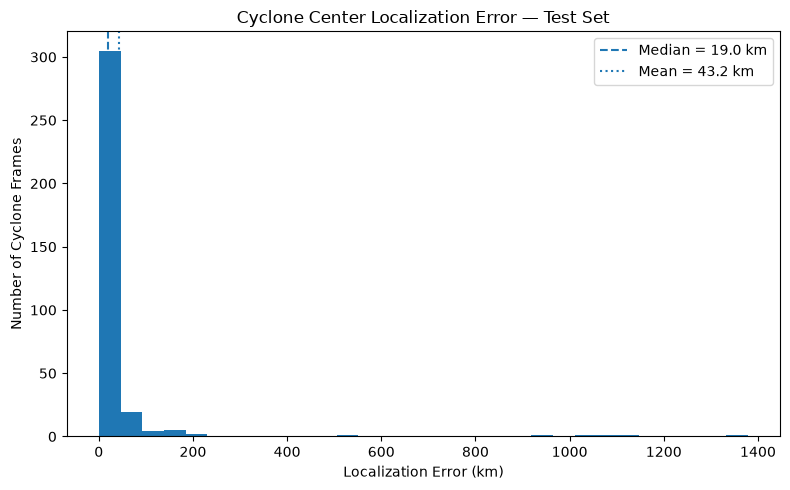

In [28]:
# ============================================================
# CELL 27 — LOCALIZATION ERROR DISTRIBUTION
# ============================================================

import matplotlib.pyplot as plt


errors = (
    test_predictions.loc[
        test_predictions[
            "actual_presence"
        ] == 1,
        "localization_error_km",
    ]
    .dropna()
    .to_numpy()
)


plt.figure(
    figsize=(8, 5)
)

plt.hist(
    errors,
    bins=30,
)

plt.axvline(
    np.median(errors),
    linestyle="--",
    label=(
        f"Median = "
        f"{np.median(errors):.1f} km"
    ),
)

plt.axvline(
    np.mean(errors),
    linestyle=":",
    label=(
        f"Mean = "
        f"{np.mean(errors):.1f} km"
    ),
)

plt.xlabel(
    "Localization Error (km)"
)

plt.ylabel(
    "Number of Cyclone Frames"
)

plt.title(
    "Cyclone Center Localization Error — Test Set"
)

plt.legend()

plt.tight_layout()

plt.show()

In [ ]:
# ============================================================
# CELL 28 — ROBUST DATA RETRIEVAL BY GLOBAL DATASET INDEX
# ============================================================

test_dataset = test_loader.dataset


# ------------------------------------------------------------
# Build mapping:
# global combined-manifest index -> local test_dataset position
# ------------------------------------------------------------

global_to_local = {
    int(global_index): local_index
    for local_index, global_index
    in enumerate(test_dataset.indices)
}


def get_mslp_for_dataset_index(
    dataset_index,
):

    dataset_index = int(
        dataset_index
    )

    if dataset_index not in global_to_local:

        raise KeyError(
            f"Dataset index {dataset_index} "
            f"is not in the test dataset."
        )

    local_index = (
        global_to_local[
            dataset_index
        ]
    )

    (
        x,
        _,
        presence,
        returned_index,
    ) = test_dataset[
        local_index
    ]

    assert int(returned_index) == dataset_index

    # Undo normalization
    mslp = (
        x[0]
        .cpu()
        .numpy()
        *
        MSLP_STD
        +
        MSLP_MEAN
    )

    return (
        mslp,
        int(
            presence.item()
        ),
    )


print(
    "Test indices mapped:",
    len(global_to_local)
)

print(
    "✓ Retrieval helper ready."
)

Test indices mapped: 682
✓ Retrieval helper ready.


In [35]:
# ============================================================
# CELL 29 — SELECT REPRESENTATIVE CASES
# ============================================================

# Most confident missed cyclone
case_fn = (
    false_negatives
    .sort_values(
        "presence_probability"
    )
    .iloc[0]
)


# Most confident false alarm
case_fp = (
    false_positives
    .sort_values(
        "presence_probability",
        ascending=False,
    )
    .iloc[0]
)


# Worst localization among detected cyclones
case_bad_loc = (
    worst_localization
    .iloc[0]
)


# Good detected cyclone:
# localization close to median
detected = (
    test_predictions[
        (test_predictions["actual_presence"] == 1)
        &
        (test_predictions["predicted_presence"] == 1)
    ]
    .copy()
)


median_error = (
    detected[
        "localization_error_km"
    ].median()
)


case_good = (
    detected.iloc[
        (
            detected[
                "localization_error_km"
            ]
            -
            median_error
        )
        .abs()
        .argsort()
        .iloc[0]
    ]
)


selected_cases = [
    (
        "False Negative",
        case_fn,
    ),
    (
        "False Positive",
        case_fp,
    ),
    (
        "Large Localization Error",
        case_bad_loc,
    ),
    (
        "Typical Correct Detection",
        case_good,
    ),
]


for title, case in selected_cases:

    print(
        title,
        "|",
        case["sample_id"],
        "| p=",
        round(
            case[
                "presence_probability"
            ],
            3,
        ),
        "| error=",
        (
            round(
                case[
                    "localization_error_km"
                ],
                1,
            )
            if pd.notna(
                case[
                    "localization_error_km"
                ]
            )
            else "N/A"
        ),
    )

False Negative | sample_002169 | p= 0.013 | error= 1042.6
False Positive | negative_000113 | p= 0.981 | error= N/A
Large Localization Error | sample_002380 | p= 0.566 | error= 224.1
Typical Correct Detection | sample_002392 | p= 1.0 | error= 18.6


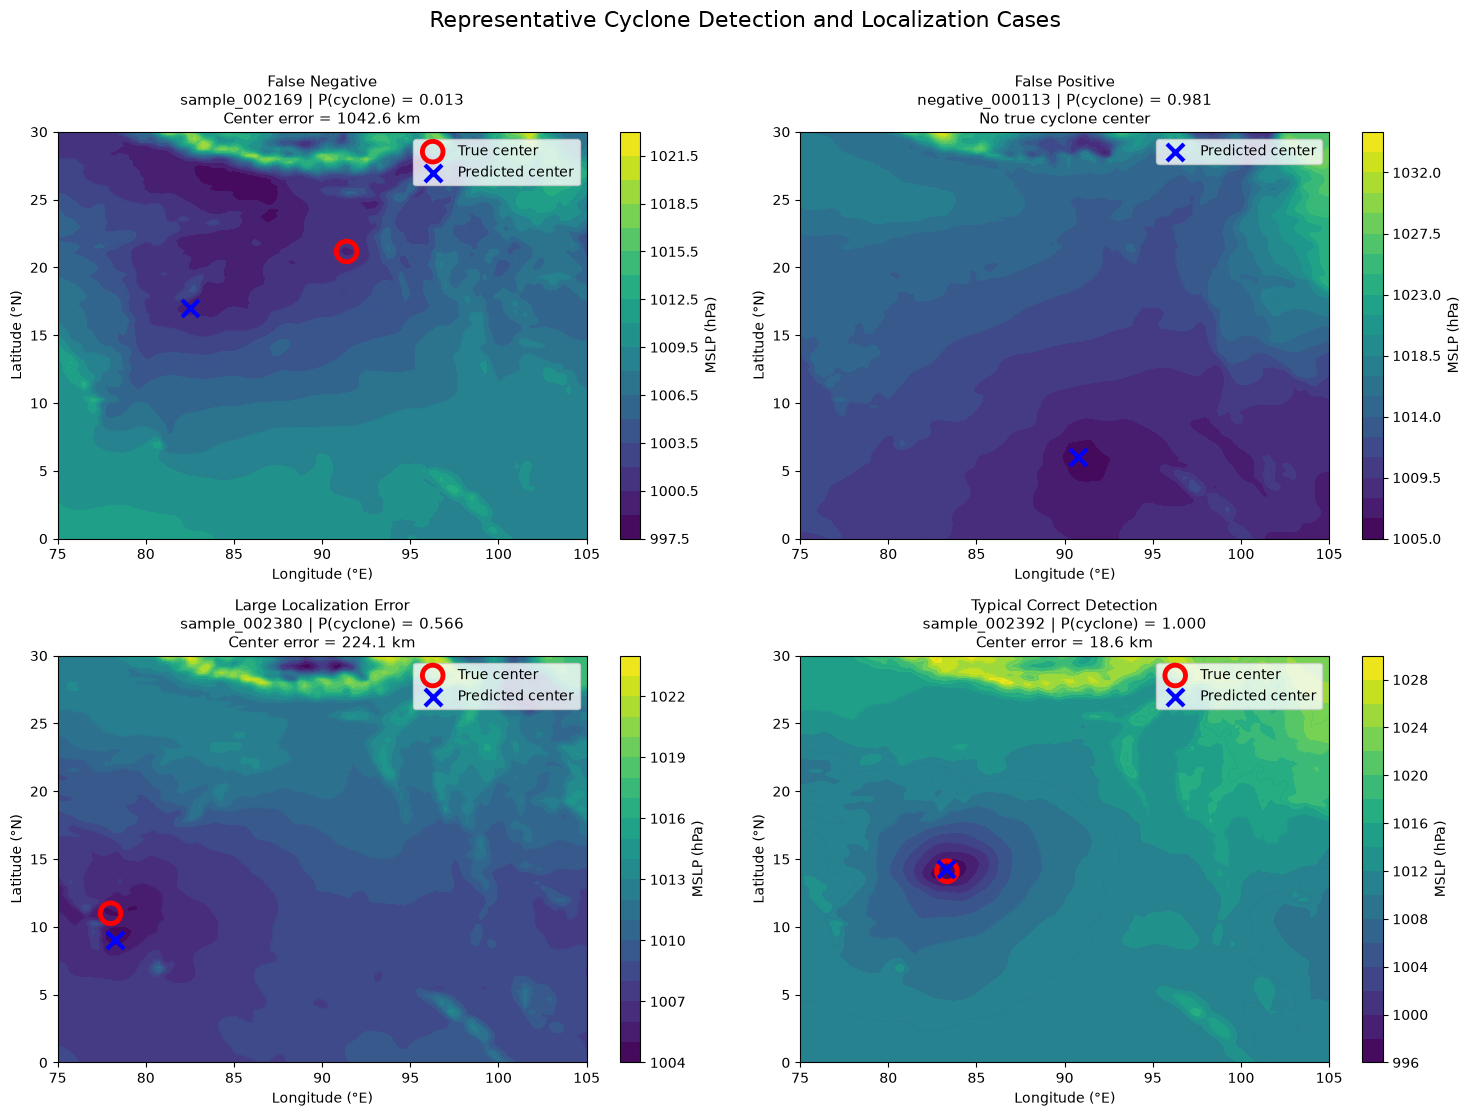

In [ ]:
# ============================================================
# CELL 30 — VISUALIZE REPRESENTATIVE FAILURE CASES
# Clear true/predicted center markers
# ============================================================

import matplotlib.pyplot as plt


fig, axes = plt.subplots(
    2,
    2,
    figsize=(15, 11),
)

axes = axes.flatten()


for ax, (title, case) in zip(
    axes,
    selected_cases,
):

    # --------------------------------------------------------
    # Retrieve MSLP
    # --------------------------------------------------------

    dataset_index = int(
        case["dataset_index"]
    )

    mslp, actual_presence = (
        get_mslp_for_dataset_index(
            dataset_index
        )
    )

    # --------------------------------------------------------
    # Plot MSLP
    # --------------------------------------------------------

    image = ax.contourf(
        longitude,
        latitude,
        mslp,
        levels=20,
    )

    ax.contour(
        longitude,
        latitude,
        mslp,
        levels=12,
        linewidths=0.5,
    )

    fig.colorbar(
        image,
        ax=ax,
        label="MSLP (hPa)",
    )

    # --------------------------------------------------------
    # TRUE CENTER
    # Draw first as a large red open circle
    # --------------------------------------------------------

    if (
        actual_presence == 1
        and
        pd.notna(case["true_lat"])
        and
        pd.notna(case["true_lon"])
    ):

        ax.scatter(
            case["true_lon"],
            case["true_lat"],
            marker="o",
            s=220,
            facecolors="none",
            edgecolors="red",
            linewidths=3.5,
            zorder=10,
            label="True center",
        )

    # --------------------------------------------------------
    # PREDICTED CENTER
    # --------------------------------------------------------

    ax.scatter(
        case["pred_lon"],
        case["pred_lat"],
        marker="x",
        s=150,
        color="blue",
        linewidths=3.0,
        zorder=11,
        label="Predicted center",
    )

    # --------------------------------------------------------
    # Probability + error
    # --------------------------------------------------------

    probability = float(
        case["presence_probability"]
    )

    if pd.notna(
        case["localization_error_km"]
    ):

        error_text = (
            f"\nCenter error = "
            f"{case['localization_error_km']:.1f} km"
        )

    else:

        error_text = (
            "\nNo true cyclone center"
        )

    ax.set_title(
        f"{title}\n"
        f"{case['sample_id']} | "
        f"P(cyclone) = {probability:.3f}"
        f"{error_text}",
        fontsize=11,
    )

    ax.set_xlabel(
        "Longitude (°E)"
    )

    ax.set_ylabel(
        "Latitude (°N)"
    )

    ax.set_xlim(
        longitude.min(),
        longitude.max(),
    )

    ax.set_ylim(
        latitude.min(),
        latitude.max(),
    )

    ax.legend(
        loc="best",
    )


fig.suptitle(
    "Representative Cyclone Detection and Localization Cases",
    fontsize=16,
    y=1.01,
)


plt.tight_layout()
plt.show()

## Optional external-data diagnostics

The remaining IBTrACS/ERA5 diagnostic cells reproduce the false-positive audit and pre-IBTrACS MSLP evolution analysis. They are **not required** to reproduce the core Experiment 03 training or test metrics. Set the placeholder paths in those cells if the original raw source files are available.


In [39]:
# ============================================================
# CELL 31A — LOAD REGIONAL IBTRACS FOR FALSE-POSITIVE AUDIT
# ============================================================

import pandas as pd
import numpy as np


IBTRACS_PATH = Path(r"PATH_TO_IBTRACS/ibtracs_all_list_v04r01.csv")


# ------------------------------------------------------------
# Load only fields needed for the audit
# ------------------------------------------------------------

ib = pd.read_csv(
    IBTRACS_PATH,
    low_memory=False,
)


print("Raw IBTrACS rows:", len(ib))


# ------------------------------------------------------------
# Parse fields
# ------------------------------------------------------------

ib["ISO_TIME"] = pd.to_datetime(
    ib["ISO_TIME"],
    utc=True,
    errors="coerce",
)

ib["LAT"] = pd.to_numeric(
    ib["LAT"],
    errors="coerce",
)

ib["LON"] = pd.to_numeric(
    ib["LON"],
    errors="coerce",
)


ib = ib.dropna(
    subset=[
        "ISO_TIME",
        "LAT",
        "LON",
    ]
).copy()


# ------------------------------------------------------------
# Same project region:
# Bay of Bengal + Myanmar regional frame
#
# Our ERA5 grid:
# latitude  0° to 30°N
# longitude 75° to 105°E
# ------------------------------------------------------------

regional_ibtracs = ib[
    (ib["LAT"] >= 0)
    &
    (ib["LAT"] <= 30)
    &
    (ib["LON"] >= 75)
    &
    (ib["LON"] <= 105)
    &
    (ib["ISO_TIME"] >= "2000-01-01")
    &
    (ib["ISO_TIME"] < "2026-01-01")
].copy()


regional_ibtracs = (
    regional_ibtracs
    .sort_values("ISO_TIME")
    .reset_index(drop=True)
)


print()
print("=" * 72)
print("REGIONAL IBTRACS FOR AUDIT")
print("=" * 72)

print(
    "Rows:",
    len(regional_ibtracs)
)

print(
    "Cyclones:",
    regional_ibtracs["SID"].nunique()
)

print(
    "Start:",
    regional_ibtracs["ISO_TIME"].min()
)

print(
    "End:",
    regional_ibtracs["ISO_TIME"].max()
)

Raw IBTrACS rows: 725185


C:\Users\USER\AppData\Local\Temp\ipykernel_8972\1546545954.py:32: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  ib["ISO_TIME"] = pd.to_datetime(



REGIONAL IBTRACS FOR AUDIT
Rows: 6132
Cyclones: 270
Start: 2000-03-27 12:00:00+00:00
End: 2025-12-02 12:00:00+00:00


In [ ]:
# ============================================================
# CELL 31B — FALSE POSITIVE TEMPORAL AUDIT
# ============================================================

audit_rows = []


for _, fp in false_positives.iterrows():

    fp_time = pd.to_datetime(
        fp["timestamp"],
        utc=True,
    )

    delta_hours = (
        (
            regional_ibtracs["ISO_TIME"]
            -
            fp_time
        )
        .dt.total_seconds()
        /
        3600.0
    )

    nearest_idx = (
        delta_hours
        .abs()
        .idxmin()
    )

    nearest = (
        regional_ibtracs.loc[
            nearest_idx
        ]
    )

    signed_hours = float(
        delta_hours.loc[
            nearest_idx
        ]
    )

    audit_rows.append(
        {
            "sample_id":
                fp["sample_id"],

            "timestamp":
                fp_time,

            "presence_probability":
                float(
                    fp["presence_probability"]
                ),

            "pred_lat":
                fp["pred_lat"],

            "pred_lon":
                fp["pred_lon"],

            "nearest_sid":
                nearest["SID"],

            "nearest_name":
                nearest["NAME"]
                if "NAME" in nearest.index
                else "UNKNOWN",

            "nearest_time":
                nearest["ISO_TIME"],

            "time_difference_hours":
                signed_hours,

            "absolute_time_difference_hours":
                abs(signed_hours),

            "ibtracs_lat":
                nearest["LAT"],

            "ibtracs_lon":
                nearest["LON"],
        }
    )


false_positive_audit = pd.DataFrame(
    audit_rows
)


false_positive_audit = (
    false_positive_audit
    .sort_values(
        "presence_probability",
        ascending=False,
    )
    .reset_index(drop=True)
)


display(
    false_positive_audit
)

,sample_id,timestamp,presence_probability,pred_lat,pred_lon,nearest_sid,nearest_name,nearest_time,time_difference_hours,absolute_time_difference_hours,ibtracs_lat,ibtracs_lon
0,negative_000113,2023-01-28 06:00:00+00:00,0.981402,6.00,90.75,2023030N08087,UNKNOWN,2023-01-30 03:00:00+00:00,45.0,45.0,7.7,87.2
1,negative_000296,2024-12-24 00:00:00+00:00,0.964776,11.50,83.25,2024356N14084,UNKNOWN,2024-12-21 06:00:00+00:00,-66.0,66.0,14.1,84.6
2,negative_000295,2024-12-22 12:00:00+00:00,0.954491,13.25,85.50,2024356N14084,UNKNOWN,2024-12-21 06:00:00+00:00,-30.0,30.0,14.1,84.6
3,negative_000071,2022-11-11 06:00:00+00:00,0.933709,9.50,81.50,2022324N10086,UNKNOWN,2022-11-20 00:00:00+00:00,210.0,210.0,10.0,85.5
4,negative_000070,2022-11-10 18:00:00+00:00,0.927378,9.25,84.00,2022324N10086,UNKNOWN,2022-11-20 00:00:00+00:00,222.0,222.0,10.0,85.5
5,negative_000112,2023-01-27 18:00:00+00:00,0.902165,4.25,91.25,2023030N08087,UNKNOWN,2023-01-30 03:00:00+00:00,57.0,57.0,7.7,87.2
6,negative_000069,2022-11-10 00:00:00+00:00,0.834571,7.25,85.00,2022324N10086,UNKNOWN,2022-11-20 00:00:00+00:00,240.0,240.0,10.0,85.5
7,negative_000315,2025-11-03 00:00:00+00:00,0.829421,17.75,94.25,2025305N08140,UNKNOWN,2025-11-07 09:00:00+00:00,105.0,105.0,15.2,104.9
8,negative_000312,2025-10-22 06:00:00+00:00,0.821767,12.00,80.00,2025300N11086,UNKNOWN,2025-10-26 12:00:00+00:00,102.0,102.0,11.3,86.1
9,negative_000294,2024-12-17 00:00:00+00:00,0.808741,10.50,82.00,2024356N14084,UNKNOWN,2024-12-20 12:00:00+00:00,84.0,84.0,13.7,83.5


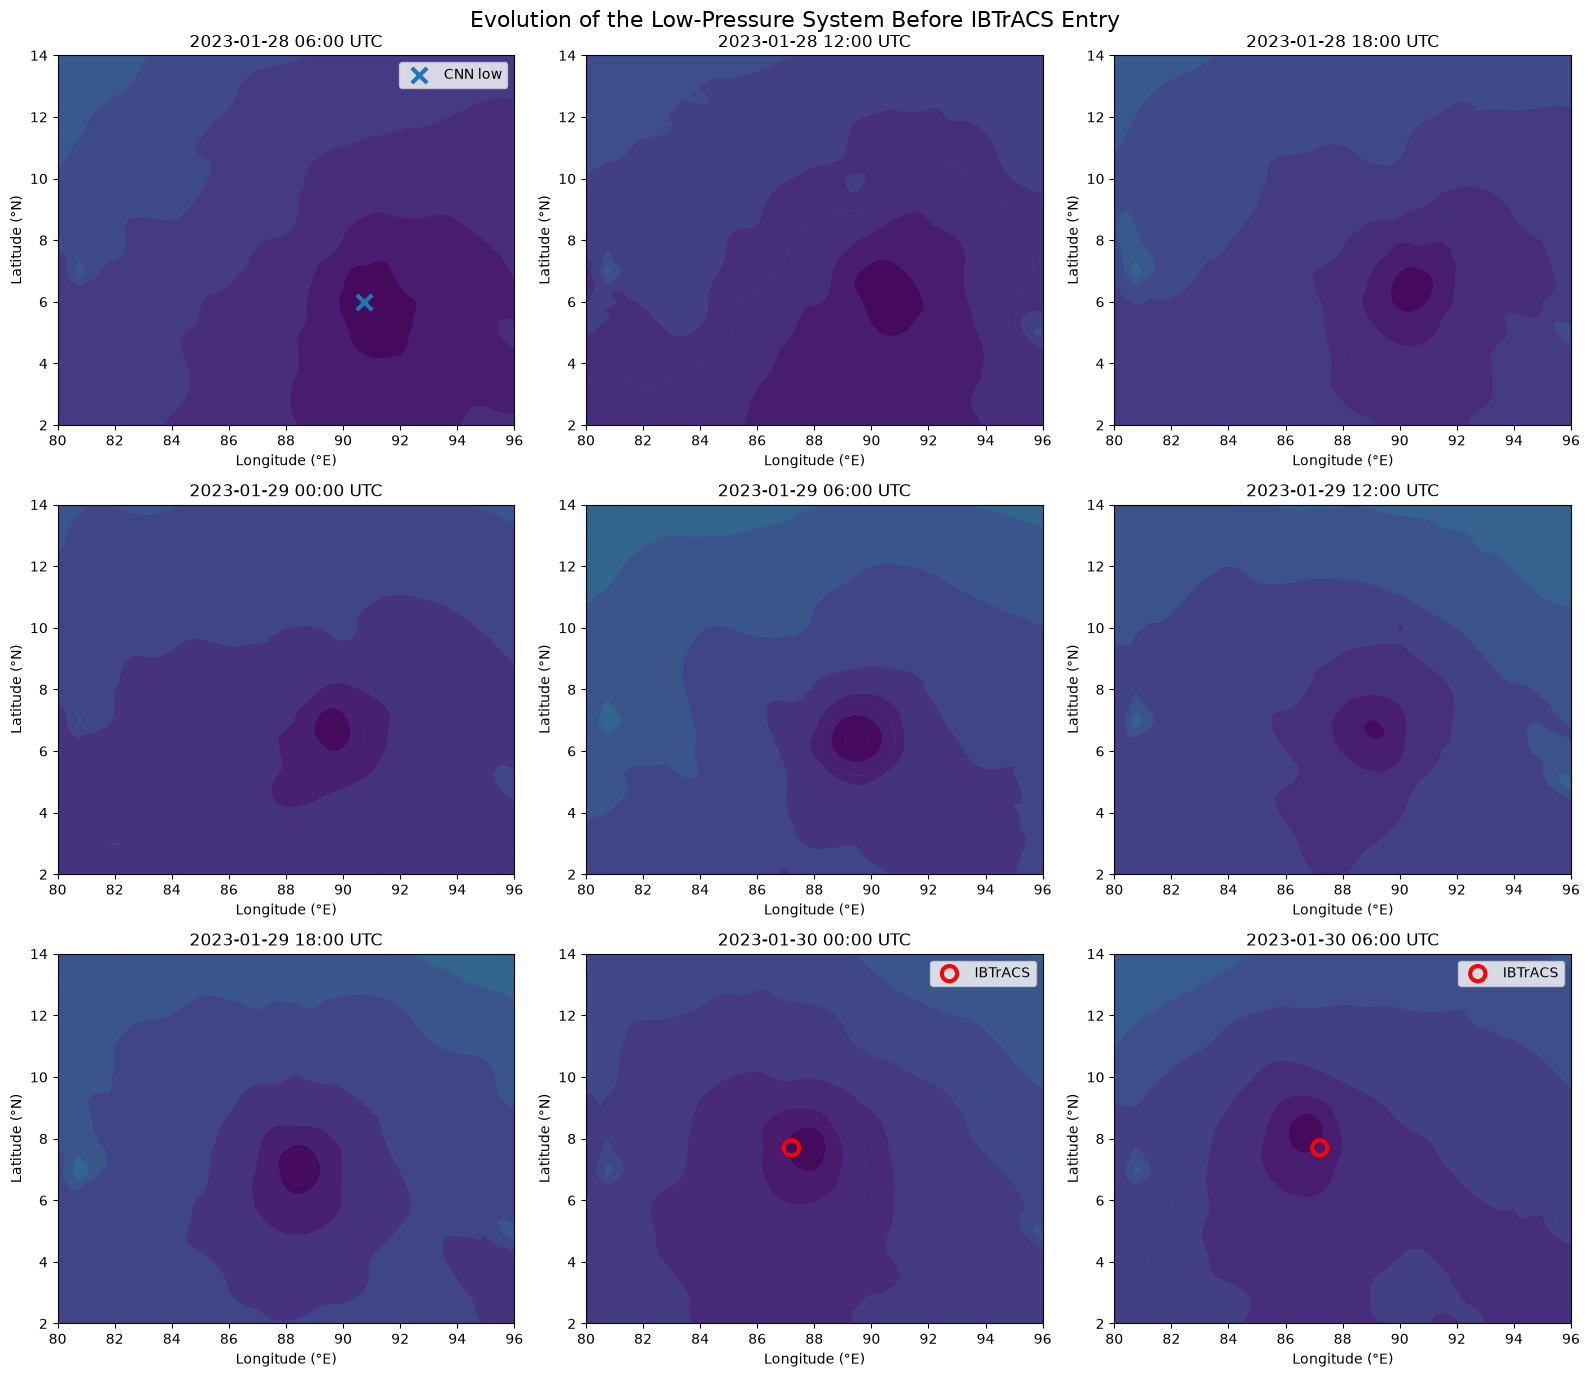

In [ ]:
# ============================================================
# CELL 33 — TRACE FALSE POSITIVE INTO NEAREST IBTRACS CYCLONE
# ============================================================

import matplotlib.pyplot as plt
import xarray as xr


CASE_TIME = pd.Timestamp(
    "2023-01-28 06:00:00+00:00"
)

IBTRACS_TIME = pd.Timestamp(
    "2023-01-30 03:00:00+00:00"
)


# 6-hourly frames from the false-positive time forward
trace_times = pd.date_range(
    start=CASE_TIME,
    end=pd.Timestamp("2023-01-30 06:00:00+00:00"),
    freq="6h",
)


single_path = Path(r"PATH_TO_ERA5/era5_single_2023_01.nc")


with xr.open_dataset(single_path) as ds:

    fig, axes = plt.subplots(
        3,
        3,
        figsize=(16, 14),
    )

    axes = axes.flatten()

    for ax, timestamp in zip(
        axes,
        trace_times,
    ):

        target_time = (
            timestamp
            .tz_convert("UTC")
            .tz_localize(None)
            .to_datetime64()
        )

        mslp = (
            ds["msl"]
            .sel(valid_time=target_time)
            .values
            .astype(np.float32)
            / 100.0
        )

        image = ax.contourf(
            longitude,
            latitude,
            mslp,
            levels=20,
        )

        ax.contour(
            longitude,
            latitude,
            mslp,
            levels=12,
            linewidths=0.5,
        )

        # ----------------------------------------------------
        # Mark original CNN-detected low only on first frame
        # ----------------------------------------------------

        if timestamp == CASE_TIME:

            ax.scatter(
                90.75,
                6.00,
                marker="x",
                s=120,
                linewidths=3,
                label="CNN low",
            )

        # ----------------------------------------------------
        # Mark nearest IBTrACS point when temporally close
        # ----------------------------------------------------

        if abs(
            (
                timestamp
                -
                IBTRACS_TIME
            ).total_seconds()
        ) <= 3 * 3600:

            ax.scatter(
                87.2,
                7.7,
                marker="o",
                s=120,
                facecolors="none",
                edgecolors="red",
                linewidths=3,
                label="IBTrACS",
            )

        ax.set_title(
            timestamp.strftime(
                "%Y-%m-%d %H:%M UTC"
            )
        )

        ax.set_xlim(
            80,
            96,
        )

        ax.set_ylim(
            2,
            14,
        )

        ax.set_xlabel(
            "Longitude (°E)"
        )

        ax.set_ylabel(
            "Latitude (°N)"
        )

        if ax.get_legend_handles_labels()[0]:
            ax.legend()

    # Hide unused panels if any
    for ax in axes[len(trace_times):]:
        ax.axis("off")

    fig.suptitle(
        "Evolution of the Low-Pressure System Before IBTrACS Entry",
        fontsize=16,
    )

    plt.tight_layout()
    plt.show()

In [ ]:
# ============================================================
# CELL 34 — TRACK MSLP MINIMUM THROUGH PRE-IBTRACS PERIOD
# ============================================================

trace_rows = []


with xr.open_dataset(single_path) as ds:

    for timestamp in trace_times:

        target_time = (
            timestamp
            .tz_convert("UTC")
            .tz_localize(None)
            .to_datetime64()
        )

        mslp = (
            ds["msl"]
            .sel(valid_time=target_time)
            .values
            .astype(np.float32)
            / 100.0
        )

        # ----------------------------------------------------
        # Restrict search to the relevant developing system
        # so unrelated regional minima cannot hijack tracking
        # ----------------------------------------------------

        lat_mask = (
            (latitude >= 3)
            &
            (latitude <= 12)
        )

        lon_mask = (
            (longitude >= 84)
            &
            (longitude <= 94)
        )

        local_field = mslp[
            np.ix_(
                lat_mask,
                lon_mask,
            )
        ]

        local_lat = latitude[
            lat_mask
        ]

        local_lon = longitude[
            lon_mask
        ]

        # ----------------------------------------------------
        # Minimum
        # ----------------------------------------------------

        row, col = np.unravel_index(
            np.argmin(local_field),
            local_field.shape,
        )

        low_lat = float(
            local_lat[row]
        )

        low_lon = float(
            local_lon[col]
        )

        low_pressure = float(
            local_field[row, col]
        )

        trace_rows.append(
            {
                "timestamp":
                    timestamp,

                "low_lat":
                    low_lat,

                "low_lon":
                    low_lon,

                "minimum_mslp_hpa":
                    low_pressure,
            }
        )


low_trace = pd.DataFrame(
    trace_rows
)


display(low_trace)

,timestamp,low_lat,low_lon,minimum_mslp_hpa
0,2023-01-28 06:00:00+00:00,6.50,90.75,1005.345642
1,2023-01-28 12:00:00+00:00,6.50,90.25,1003.688110
2,2023-01-28 18:00:00+00:00,6.25,90.50,1004.357483
3,2023-01-29 00:00:00+00:00,6.75,89.50,1003.052490
4,2023-01-29 06:00:00+00:00,6.50,89.50,1003.741272
5,2023-01-29 12:00:00+00:00,6.75,89.00,1003.260010
6,2023-01-29 18:00:00+00:00,7.25,88.50,1005.286865
7,2023-01-30 00:00:00+00:00,7.75,87.75,1003.761902
8,2023-01-30 06:00:00+00:00,8.25,86.75,1005.597473


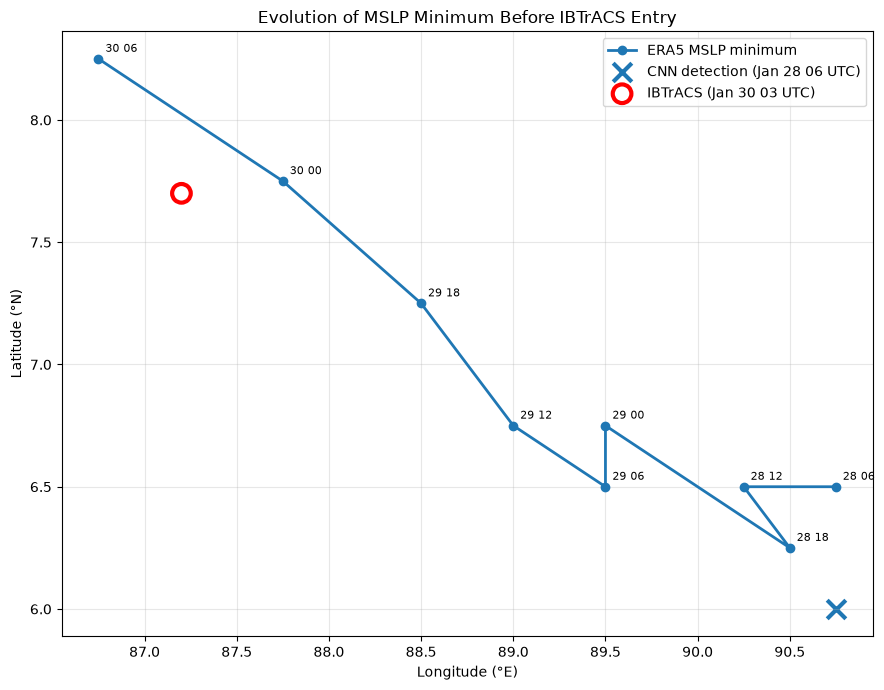

In [43]:
# ============================================================
# CELL 35 — PRE-IBTRACS LOW-PRESSURE TRAJECTORY
# ============================================================

plt.figure(
    figsize=(9, 7)
)


# Low-pressure trajectory
plt.plot(
    low_trace["low_lon"],
    low_trace["low_lat"],
    marker="o",
    linewidth=2,
    label="ERA5 MSLP minimum",
)


# Starting CNN detection
plt.scatter(
    90.75,
    6.00,
    marker="x",
    s=180,
    linewidths=3,
    label="CNN detection (Jan 28 06 UTC)",
)


# First nearby IBTrACS observation
plt.scatter(
    87.2,
    7.7,
    marker="o",
    s=180,
    facecolors="none",
    edgecolors="red",
    linewidths=3,
    label="IBTrACS (Jan 30 03 UTC)",
)


# Timestamp labels
for _, row in low_trace.iterrows():

    plt.annotate(
        row["timestamp"].strftime(
            "%d %H"
        ),
        (
            row["low_lon"],
            row["low_lat"],
        ),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=8,
    )


plt.xlabel(
    "Longitude (°E)"
)

plt.ylabel(
    "Latitude (°N)"
)

plt.title(
    "Evolution of MSLP Minimum Before IBTrACS Entry"
)

plt.grid(
    alpha=0.3
)

plt.legend()

plt.tight_layout()
plt.show()

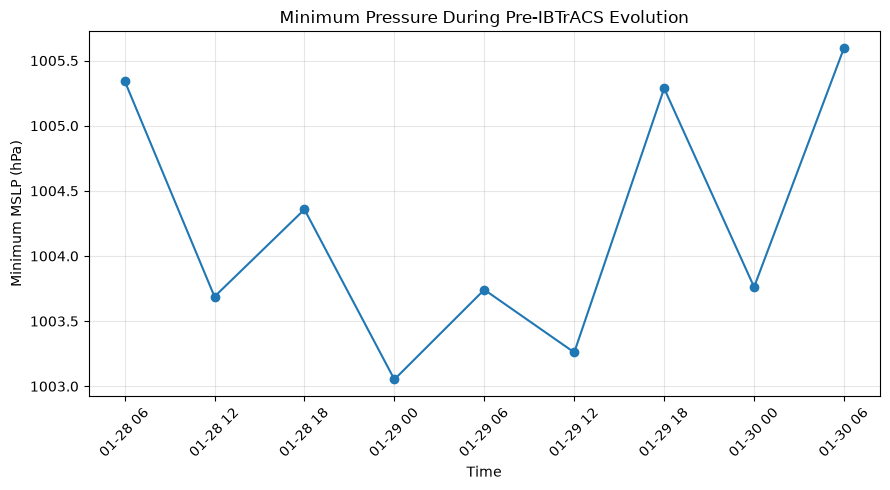

In [44]:
# ============================================================
# CELL 36 — MINIMUM PRESSURE EVOLUTION
# ============================================================

plt.figure(
    figsize=(9, 5)
)


plt.plot(
    low_trace["timestamp"],
    low_trace["minimum_mslp_hpa"],
    marker="o",
)


plt.xlabel(
    "Time"
)

plt.ylabel(
    "Minimum MSLP (hPa)"
)

plt.title(
    "Minimum Pressure During Pre-IBTrACS Evolution"
)

plt.xticks(
    rotation=45
)

plt.grid(
    alpha=0.3
)

plt.tight_layout()
plt.show()